# Per-mutant COLVAR clustering by `rmsd_ca`

Clusters combined folded + unfolded COLVAR (COLVAR_CV_F + COLVAR_CV_UF) per mutant with fixed k=2 on `rmsd_ca` only (no descriptors). Applies `rmsd_weight` if you want to upweight RMSD in k-means space. Outputs one plot with sorted `rmsd_ca` centers and per-cluster ranges: blue=low center, red=high center; size = cluster population; horizontal line shows [min,max] rmsd in that cluster.


In [35]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.cluster import vq

plt.style.use("seaborn-v0_8")

In [36]:
# --- configuration ---
base_dir = Path("../data/traj")
f_filename = "COLVAR_CV_F"
uf_filename = "COLVAR_CV_UF"

sample_rows = 400_000      # max rows to keep per mutant (combined F+UF)
n_clusters = 2             # fixed to 2 clusters (low/high)
rmsd_weight = 3.0          # >1 emphasizes rmsd_ca in clustering

# To focus on a subset, list mutant folder names (e.g., ["D2A", "E4A"]).
# Set to None to scan all mutants under base_dir.
mutant_subset = None

rng = np.random.default_rng(0)


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.cluster import vq

plt.style.use("seaborn-v0_8")


def read_colvar_header_names(path: Path) -> list[str]:
    """Extract PLUMED column names from the header line."""
    with path.open() as f:
        header = next(line for line in f if line.startswith("#!"))
    return header.strip().split()[2:]


def load_colvar(path: Path, usecols: list[str], nrows: int | None = None) -> pd.DataFrame:
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        names=read_colvar_header_names(path),
        engine="python",
        usecols=usecols,
        nrows=nrows,
    )


def prepare_features(df: pd.DataFrame, rmsd_weight: float):
    X = df[["rmsd_ca"]].to_numpy(dtype=float)
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0
    Xz = (X - mean) / std
    Xz[:, 0] *= rmsd_weight
    return X, Xz, mean, std


def kmeans_fixed(Xz: np.ndarray, k: int, rng):
    centroids, labels = vq.kmeans2(Xz, k, minit="points", iter=60, rng=rng)
    return centroids, labels.astype(int)


Found 38 mutants
D2A: rmsd_ca centers (F+UF, sorted low→high): [0.2279 0.6755]; ranges [(np.float64(0.0693), np.float64(0.4517)), (np.float64(0.4517), np.float64(0.9652))]
D2C: rmsd_ca centers (F+UF, sorted low→high): [0.2457 0.6736]; ranges [(np.float64(0.0541), np.float64(0.4596)), (np.float64(0.4597), np.float64(1.0537))]
D2E: rmsd_ca centers (F+UF, sorted low→high): [0.2158 0.6664]; ranges [(np.float64(0.0643), np.float64(0.4411)), (np.float64(0.4411), np.float64(1.0))]
D2K: rmsd_ca centers (F+UF, sorted low→high): [0.221  0.6974]; ranges [(np.float64(0.0545), np.float64(0.4592)), (np.float64(0.4592), np.float64(1.0522))]
D2M: rmsd_ca centers (F+UF, sorted low→high): [0.2238 0.6483]; ranges [(np.float64(0.072), np.float64(0.436)), (np.float64(0.436), np.float64(1.0351))]
D2N: rmsd_ca centers (F+UF, sorted low→high): [0.2288 0.6787]; ranges [(np.float64(0.0824), np.float64(0.4538)), (np.float64(0.4538), np.float64(1.0354))]
D2R: rmsd_ca centers (F+UF, sorted low→high): [0.2262 0.636

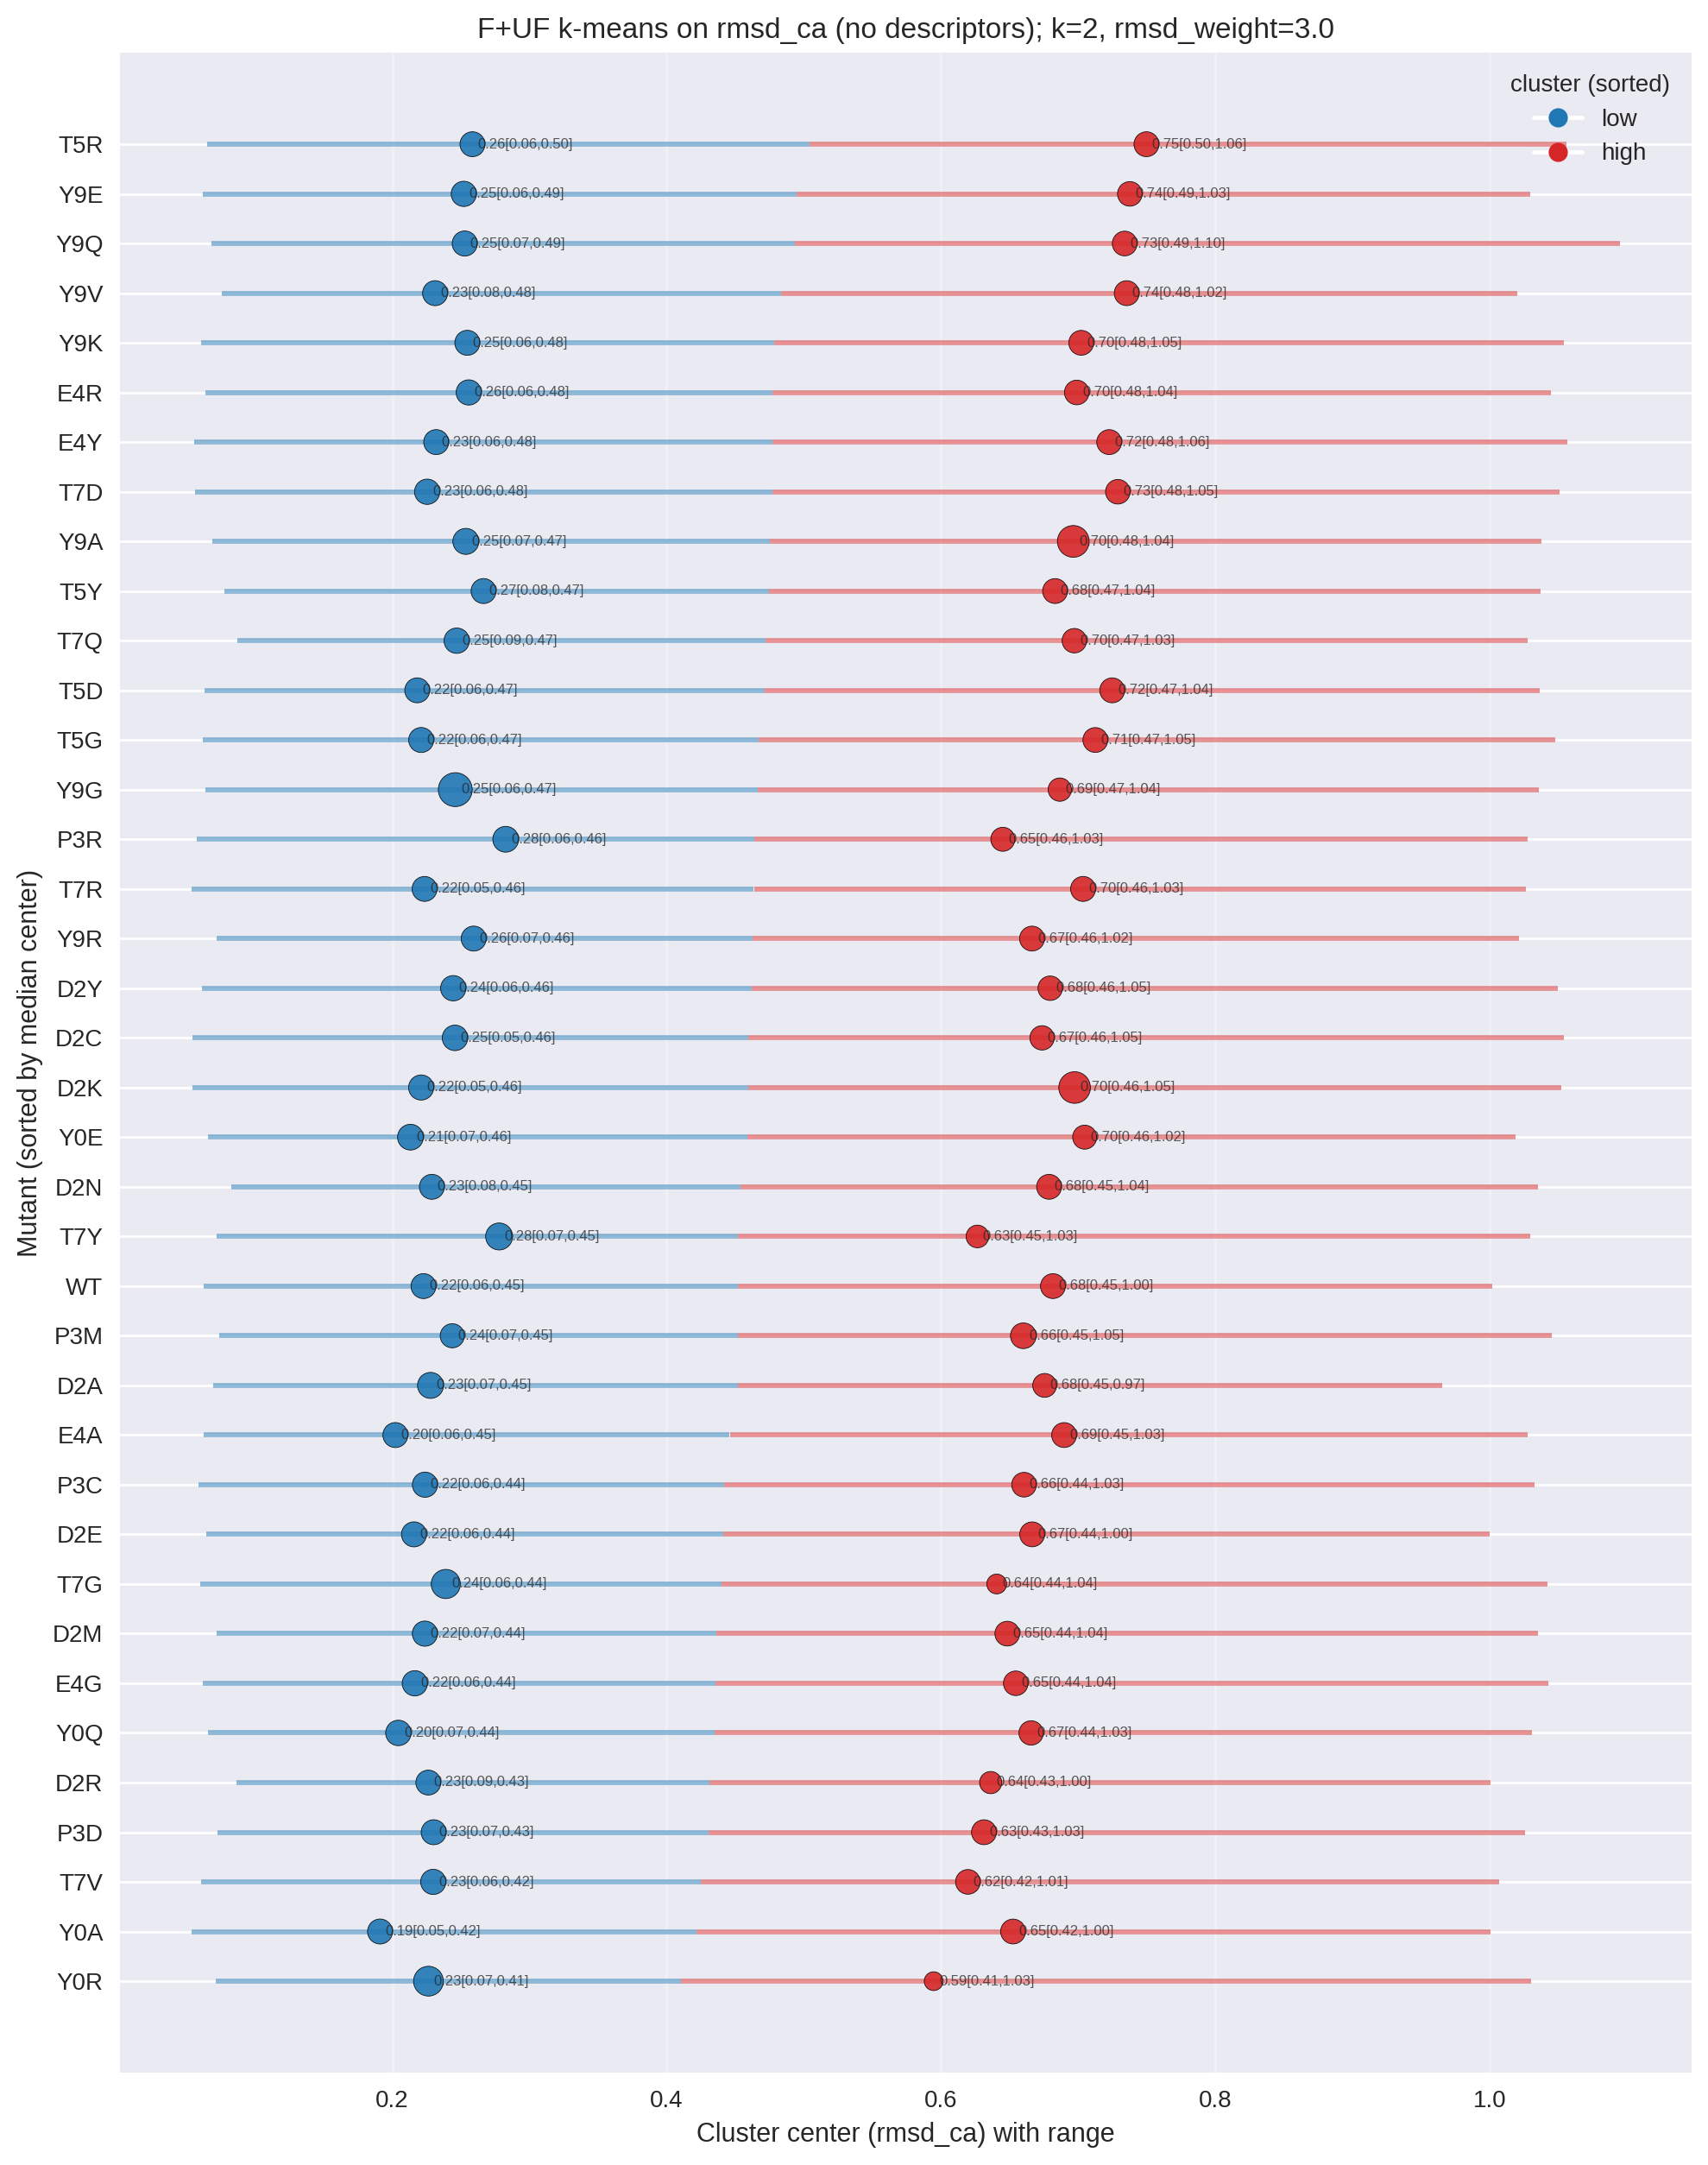

In [38]:
mutant_dirs = [d for d in base_dir.iterdir() if d.is_dir()]
if mutant_subset:
    mutant_dirs = [d for d in mutant_dirs if d.name in mutant_subset]

mutant_dirs = sorted(mutant_dirs, key=lambda p: p.name)
print(f"Found {len(mutant_dirs)} mutants")

rows = []  # per-cluster summary rows

for protein_dir in mutant_dirs:
    short = protein_dir.name
    f_path = protein_dir / f_filename
    uf_path = protein_dir / uf_filename

    if not f_path.exists() or not uf_path.exists():
        print(f"{short}: missing COLVAR files, skipping")
        continue

    usecols = ["rmsd_ca"]

    df_F = load_colvar(f_path, usecols=usecols, nrows=sample_rows)
    df_UF = load_colvar(uf_path, usecols=usecols, nrows=sample_rows)

    df_F["state"] = "F"
    df_UF["state"] = "UF"
    df = pd.concat([df_F, df_UF], ignore_index=True)
    df = df.dropna().reset_index(drop=True)

    if len(df) > sample_rows:
        df = df.sample(sample_rows, random_state=0).reset_index(drop=True)

    if df.empty:
        print(f"{short}: no data loaded")
        continue

    X, Xz, mean, std = prepare_features(df, rmsd_weight)
    centroids_z, labels = kmeans_fixed(Xz, n_clusters, rng)

    centroids = centroids_z.copy()
    centroids[:, 0] /= rmsd_weight
    centroids_orig = centroids * std + mean

    rmsd_centers = centroids_orig[:, 0]
    order = np.argsort(rmsd_centers)
    centers_sorted = rmsd_centers[order]
    counts_sorted = [(labels == idx).sum() for idx in order]
    ranges_sorted = [
        (df.loc[labels == idx, "rmsd_ca"].min(), df.loc[labels == idx, "rmsd_ca"].max())
        for idx in order
    ]
    levels = ["low", "high"][: len(centers_sorted)]

    for level, center, count, (rmin, rmax) in zip(levels, centers_sorted, counts_sorted, ranges_sorted):
        rows.append({
            "Mutant": short,
            "level": level,
            "center": float(center),
            "n": int(count),
            "rmin": float(rmin),
            "rmax": float(rmax),
        })

    print(
        f"{short}: rmsd_ca centers (F+UF, sorted low→high): {np.round(centers_sorted, 4)}; ranges {[tuple(round(v,4) for v in rr) for rr in ranges_sorted]}"
    )

if not rows:
    print("No mutants processed")
else:
    centers_df = pd.DataFrame(rows)
    order = (
        centers_df.groupby("Mutant")
        ["center"].median()
        .sort_values()
        .index
        .tolist()
    )
    centers_df["Mutant"] = pd.Categorical(centers_df["Mutant"], categories=order, ordered=True)
    centers_df = centers_df.sort_values(["Mutant", "center"]).reset_index(drop=True)

    n_max = centers_df["n"].max() if len(centers_df) else 1
    sizes = 40 + 160 * (centers_df["n"] / n_max)

    palette = {"low": "#1f77b4", "high": "#d62728"}
    colors = centers_df["level"].map(palette)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.28 * len(order) + 2)), dpi=200)
    ax.scatter(
        centers_df["center"],
        centers_df["Mutant"],
        s=sizes,
        c=colors,
        alpha=0.9,
        edgecolor="k",
        linewidth=0.3,
        zorder=3,
    )

    for _, row in centers_df.iterrows():
        ax.hlines(
            y=row["Mutant"],
            xmin=row["rmin"],
            xmax=row["rmax"],
            colors=palette[row["level"]],
            alpha=0.5,
            linewidth=2.0,
            zorder=2,
        )

    for _, row in centers_df.iterrows():
        ax.text(
            row["center"] + 0.004,
            row["Mutant"],
            f"{row['center']:.2f}[{row['rmin']:.2f},{row['rmax']:.2f}]",
            va="center",
            ha="left",
            fontsize=6,
            alpha=0.75,
        )

    ax.set_xlabel("Cluster center (rmsd_ca) with range")
    ax.set_ylabel("Mutant (sorted by median center)")
    ax.set_title(
        f"F+UF k-means on rmsd_ca (no descriptors); k=2, rmsd_weight={rmsd_weight}"
    )
    ax.grid(True, axis="x", alpha=0.3)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', label='low', markerfacecolor=palette['low'], markersize=8, markeredgecolor='k'),
        plt.Line2D([0], [0], marker='o', color='w', label='high', markerfacecolor=palette['high'], markersize=8, markeredgecolor='k')
    ]
    ax.legend(handles=handles, title="cluster (sorted)")

    fig.tight_layout()
    plt.show()
